In [ ]:
import gensim.downloader as api
from gensim.models import KeyedVectors
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
import scipy.spatial.distance as ssd

from nltk.tag import pos_tag
from nltk.tokenize import word_tokenize
import nltk
nltk.download('universal_tagset')

from nltk.corpus import wordnet as wn
nltk.download('wordnet', quiet=True)

import os
from pprint import pprint

from collections import Counter

[nltk_data] Downloading package universal_tagset to
[nltk_data]     /home/pe/nltk_data...
[nltk_data]   Package universal_tagset is already up-to-date!


# Load GG pretrain and some function

In [ ]:
def save_sub_emb(words:list[str], model:KeyedVectors, path:str)->list[str]:
    """
    Save embeddings for words present in the given KeyedVectors model to a .npz file.

    Parameters
    ----------
    words : list[str]
        List of words to extract embeddings for.
    model : KeyedVectors
        Gensim KeyedVectors instance containing pretrained embeddings.
    path : str---
        Path to save the resulting .npz file. The file will contain two arrays:
        - "vectors": numpy array of shape (N_found_words, embedding_dim)
        - "words": list of found words in the same order as vectors

    Returns
    -------
    list[str]
        List of words from `words` that were not found in the model.
    """
    big_and_small_corpus = []
    valid_vectors = []
    no_valid_word = []
    for w in words :
        if model.has_index_for(w):
            big_and_small_corpus.append(w)
            valid_vectors.append(model[w])
        else:
            no_valid_word.append(w)
    # Shape will be (N_words, 300)
    google_matrix = np.array(valid_vectors)
    np.savez(
        path,
        vectors=google_matrix, 
        words=big_and_small_corpus
    )
    
    return no_valid_word
    
def save_sub_embeddings_for_corpora_from_model(paths:dict[str, str], model:KeyedVectors, path_to_save:str='.') -> dict:
    """
    For each .npz file in `paths` (expected to contain an array 'words'),
    save the corresponding embeddings extracted from `model` to a new .npz
    placed alongside the original file with suffix '_google_sub_embed.npz'.
    
    Parameters
    -------
    paths : Dict[str, str]
        Dico contain path of model, keys corresponding to name of model
    
    Returns
    -------
    a dict mapping input path -> list of words not found in `model`.
    """
    missing_word = {}
    for name_model, path in paths.items():
        model_tempo = np.load(path)
        word_of_corpus = model_tempo['words'].tolist()
        
        out_path = f"{path_to_save}/google_sub_embed_{name_model}.npz" 
        missing = save_sub_emb(word_of_corpus, model, out_path)
        missing_word[name_model] = missing
    return missing_word

def create_cos_similarity(words: list[str], model: KeyedVectors) -> pd.DataFrame:
    """
    Computes a pairwise cosine similarity matrix for a list of words.

    Args:
        words (List[str]): The vocabulary list to compare.
        model (KeyedVectors): A trained Gensim Word2Vec/FastText model.

    Returns:
        pd.DataFrame: A symmetric DataFrame of shape (len(words), len(words)) 
                      where cell [i, j] contains the cosine similarity between word i and word j.
    """
    res = np.zeros((len(words), len(words)), dtype=float)
    for i, w1 in enumerate(words):
        for j, w2 in enumerate(words):
            res[i][j] = model.similarity(w1, w2)
            
    df_similarity = pd.DataFrame(res, columns=words, index=words)
    return df_similarity

def create_all_clusters(all_cosine_similarity: pd.DataFrame, min_similarity: float = 0.5) -> dict[int, list[str]]:
    """
    Performs hierarchical agglomerative clustering on a similarity matrix.

    Args:
        all_cosine_similarity (pd.DataFrame): The pairwise similarity matrix from `create_cos_similarity`.
        min_similarity (float): The minimum similarity required for words to be grouped together. 
                                A higher value (e.g., 0.8) creates smaller, tighter clusters.

    Returns:
        Dict[int, List[str]]: A dictionary mapping a unique cluster ID (int) to its list of words.
    """
    dist_matrix = 1.0 - all_cosine_similarity.values
    np.fill_diagonal(dist_matrix, 0.0) 
    
    condensed_dist = ssd.squareform(dist_matrix)
    Z = linkage(condensed_dist, method='complete')
    distance_threshold = 1.0 - min_similarity
    cluster_labels = fcluster(Z, t=distance_threshold, criterion='distance')
    
    clusters: dict[int, list[str]] = {}
    words = all_cosine_similarity.index
    
    for word, label in zip(words, cluster_labels):
        if label not in clusters:
            clusters[label] = []
        clusters[label].append(word)
        
    return clusters, Z
    
def find_good_clusters(clusters: dict[int, list[str]], df_similarity: pd.DataFrame, min_words: int) -> list[tuple[int, float, list[str]]]:
    """
    Filters clusters by size and calculates the average internal cohesion (tightness) of each.

    Args:
        clusters (Dict[int, List[str]]): The output from `create_all_clusters`.
        df_similarity (pd.DataFrame): The original similarity matrix.
        min_words (int): The minimum number of words a cluster must contain to be kept.

    Returns:
        List[Tuple[int, float, List[str]]]: A list of valid clusters sorted by cohesion (highest first).
                                            Format: [(cluster_id, avg_similarity, word_list), ...]
    """
    valid_clusters = []
    
    for cluster_id, words in clusters.items():
        if len(words) >= min_words:
            sub_matrix = df_similarity.loc[words, words]
            mask = np.triu(np.ones(sub_matrix.shape), k=1).astype(bool)
            
            avg_similarity = sub_matrix.values[mask].mean()
            std_similarity = sub_matrix.values[mask].std()
            
            valid_clusters.append((cluster_id, avg_similarity, std_similarity, words))
            
    valid_clusters.sort(key=lambda x: x[1], reverse=True)
            
    return valid_clusters

def analyze_cluster_pos_tag(cluster_words: list[str]) -> dict[str, float]:
    """
    Analyzes a list of words to determine the percentage of Nouns, Verbs, etc.
    
    Args:
        cluster_words (List[str]): The list of words in your cluster.
        
    Returns:
        Dict[str, float]: A dictionary with the POS tags as keys and their 
                          percentage (0-100) in the cluster as values.
    """
    pos_counts = Counter()

    for word in cluster_words:
        tagged = nltk.pos_tag([word], tagset='universal')
        tag = tagged[0][1] 
        pos_counts[tag] += 1
        
    total_words = len(cluster_words)
    pos_percentages = {}
    for tag, count in pos_counts.items():
        percentage = (count / total_words) * 100
        pos_percentages[tag] = percentage
        
    return dict(sorted(pos_percentages.items(), key=lambda item: item[1], reverse=True))

def analyze_cluster_WordNet(cluster_words: list[str]) -> dict[str, float]:
    """
    Analyzes a list of isolated words using WordNet dictionary frequencies 
    to determine the percentage of Nouns, Verbs, Adjectives, etc.
    
    Args:
        cluster_words (List[str]): The list of words in your cluster.
        
    Returns:
        Dict[str, float]: A dictionary with the POS tags as keys and their 
                          percentage (0-100) in the cluster as values.
    """
    pos_counts = Counter()
    
    # Map WordNet's internal tags to clean Universal tags
    tag_map = {
        'n': 'NOUN',
        'v': 'VERB',
        'a': 'ADJ',  # Adjective
        's': 'ADJ',  # Adjective satellite (treated the same as ADJ)
        'r': 'ADV'   # Adverb
    }
    
    for word in cluster_words:
        # Fetch all dictionary definitions for the word
        synsets = wn.synsets(word)
        
        if not synsets:
            # WordNet might not know highly specific jargon, slang, or typos
            most_common_def = "UNKNOWN"
        else:
            # synsets[0] is always the most statistically common definition
            most_common_def = synsets[0].pos()
            # tag = tag_map.get(most_common_def, 'OTHER')

        pos_counts[most_common_def] += 1
        
    # Calculate percentages
    total_words = len(cluster_words)
    pos_percentages = {}
    
    for tag, count in pos_counts.items():
        percentage = (count / total_words) * 100
        pos_percentages[tag] = round(percentage, 1) # Round to 1 decimal place
        
    # Sort the dictionary so the dominant POS is first
    sorted_percentages = dict(sorted(pos_percentages.items(), key=lambda item: item[1], reverse=True))
    
    return sorted_percentages


In [4]:
model_path = './GoogleNews-vectors-negative300.bin.gz'
model:KeyedVectors = KeyedVectors.load_word2vec_format(model_path, binary=True)

# Create save of sub emb of Google model

In [5]:
experiment_paths = {}
    
# 1. Loop through Level 1 (e.g., GNG, TS, etc.)
# for model_type in os.listdir('../embedding'):

for step in range(0, 7):
    for corpus in ["GNG"]:
        model_path = os.path.join('../embedding', corpus)
        
        full_path = f"../embedding/{corpus}/noNorm/by_step_250/{step}/seed_0_SkipGramModel_.npz"
        if not os.path.isfile(full_path):
            continue
        experiment_paths[corpus] = full_path
                
    print(experiment_paths)

    os.makedirs(f"by_step_250/{step}", exist_ok=True)
    missing_word = save_sub_embeddings_for_corpora_from_model(experiment_paths,
                                                            model=model,path_to_save=f"by_step_250/{step}")
    print(missing_word)

{'GNG': '../embedding/GNG/noNorm/by_step_250/0/seed_0_SkipGramModel_.npz'}
{'GNG': ['a', 'and', 'byebye', 'to']}
{'GNG': '../embedding/GNG/noNorm/by_step_250/1/seed_0_SkipGramModel_.npz'}
{'GNG': ['a', 'and', 'byebye', 'rooooar', 'streeeeetch', 'to']}
{'GNG': '../embedding/GNG/noNorm/by_step_250/2/seed_0_SkipGramModel_.npz'}
{'GNG': ['a', 'and', 'byebye', 'grey', 'rooooar', 'streeeeetch', 'to']}
{'GNG': '../embedding/GNG/noNorm/by_step_250/3/seed_0_SkipGramModel_.npz'}
{'GNG': ['a', 'and', 'byebye', 'grey', 'of', 'rooooar', 'streeeeetch', 'to']}
{'GNG': '../embedding/GNG/noNorm/by_step_250/4/seed_0_SkipGramModel_.npz'}
{'GNG': ['a', 'and', 'byebye', 'grey', 'of', 'rooooar', 'streeeeetch', 'to', 'yaaaawn']}
{'GNG': '../embedding/GNG/noNorm/by_step_250/5/seed_0_SkipGramModel_.npz'}
{'GNG': ['a', 'and', 'byebye', 'grey', 'of', 'rooooar', 'streeeeetch', 'to', 'yaaaawn']}
{'GNG': '../embedding/GNG/noNorm/by_step_250/6/seed_0_SkipGramModel_.npz'}
{'GNG': ['a', 'and', 'byebye', 'grey', 'of', 

In [6]:
model_tempo = np.load("../embedding/GNG/noNorm/by_step_250/6/seed_0_SkipGramModel_.npz")
words = model_tempo['words']
print(words)
    

['a' 'across' 'again' 'alarm' 'all' 'alone' 'already' 'and' 'animal'
 'animals' 'another' 'answering' 'anymore' 'are' 'armadillo' 'as' 'asleep'
 'at' 'ate' 'awake' 'away' 'baby' 'back' 'ball' 'balloon' 'banana'
 'barely' 'be' 'because' 'bed' 'bedroom' 'behind' 'being' 'belong'
 'belongs' 'belt' 'bicycle' 'big' 'black' 'blanket' 'blink' 'blue' 'bone'
 'bottle' 'busted' 'busy' 'but' 'by' 'byebye' 'cage' 'can' 'cap' 'carpet'
 'cat' 'catch' 'click' 'climbing' 'climbs' 'clink' 'clock' 'clomp'
 'closely' 'closer' 'come' 'comes' 'comfy' 'coming' 'covers' 'crawled'
 'cuddled' 'curled' 'curtains' 'dark' 'dear' 'deep' 'did' 'different' 'do'
 'does' 'doesnot' 'doing' 'doll' 'donot' 'door' 'down' 'drag' 'dragging'
 'drawer' 'dropped' 'duck' 'edge' 'elephant' 'else' 'even' 'everyone'
 'everything' 'eyes' 'fast' 'finally' 'finding' 'finger' 'fits'
 'flashlight' 'floating' 'floor' 'fluffy' 'fly' 'follow' 'following'
 'foot' 'for' 'found' 'free' 'friend' 'friends' 'from' 'front' 'full'
 'fuzzy' 'gate'

# Create clusters

In [7]:
min_similarity=0.4
min_words=5

In [8]:
corpus_emb = {
    "GNG" : "google_sub_embed_GNG.npz",
    # "IWW" : "google_sub_embed_IWW.npz",
    # "TGTR" : "google_sub_embed_TGTR.npz",
    # "TS_GNG_IWW" : "google_sub_embed_TS_GNG_IWW.npz",
    # "TS" : "google_sub_embed_TS.npz",
    # "TSGE" : "google_sub_embed_TSGE.npz",
    # "TRDP" : "google_sub_embed_TRDP.npz",
}

list_df_sim = []
cluster_by_corpus = {}
for corpus_name, corpus_path in corpus_emb.items():
    model_tempo = np.load(corpus_path)
    words = model_tempo['words']
    df_sim = create_cos_similarity(words, model)
    list_df_sim.append(df_sim)
    all_clusters, _ = create_all_clusters(df_sim, min_similarity=min_similarity)
    best_clusters = find_good_clusters(all_clusters, df_sim, min_words=min_words)
    cluster_by_corpus[corpus_name] = best_clusters
    print(f"\n--- Top Clusters ({len(best_clusters)}) by Cohesion (Tightness) for {corpus_name} ---")
    for cluster_id, score, std_score, words in best_clusters:
        print(f"Cluster {cluster_id} | Cohesion: {score:.3f}  +- {std_score:.2f}| Words: {words}")


--- Top Clusters (7) by Cohesion (Tightness) for GNG ---
Cluster 162 | Cohesion: 0.604  +- 0.09| Words: ['did', 'do', 'does', 'going', 'not', 'want']
Cluster 118 | Cohesion: 0.595  +- 0.10| Words: ['black', 'blue', 'orange', 'pink', 'purple', 'white', 'yellow']
Cluster 33 | Cohesion: 0.569  +- 0.06| Words: ['asleep', 'awake', 'bed', 'sleep', 'sleeping']
Cluster 38 | Cohesion: 0.557  +- 0.06| Words: ['cat', 'elephant', 'giraffe', 'gorilla', 'monkey']
Cluster 87 | Cohesion: 0.553  +- 0.07| Words: ['away', 'back', 'down', 'off', 'out', 'up']
Cluster 164 | Cohesion: 0.545  +- 0.10| Words: ['here', 'just', 'me', 'really', 'us']
Cluster 168 | Cohesion: 0.526  +- 0.08| Words: ['because', 'but', 'even', 'it', 'never', 'that']


In [45]:
min_similarity=0.4
min_words=2

model_tempo = np.load(f"by_step_250/0/google_sub_embed_GNG.npz")
words = model_tempo['words']
df_sim = create_cos_similarity(words, model)
all_clusters, Z = create_all_clusters(df_sim, min_similarity=min_similarity)
best_clusters = find_good_clusters(all_clusters, df_sim, min_words=min_words)
print(f"\n--- Top Clusters ({len(best_clusters)}) by Cohesion (Tightness) ---")
for cluster_id, score, std_score, words in best_clusters:
    print(f"Cluster {cluster_id} | Cohesion: {score:.3f}  +- {std_score:.2f}| Words: {words}")



--- Top Clusters (24) by Cohesion (Tightness) ---
Cluster 44 | Cohesion: 0.703  +- 0.00| Words: ['oh', 'uh']
Cluster 54 | Cohesion: 0.656  +- 0.00| Words: ['coming', 'going']
Cluster 62 | Cohesion: 0.641  +- 0.00| Words: ['know', 'say']
Cluster 17 | Cohesion: 0.638  +- 0.02| Words: ['he', 'him', 'his']
Cluster 38 | Cohesion: 0.610  +- 0.00| Words: ['pink', 'yellow']
Cluster 63 | Cohesion: 0.609  +- 0.00| Words: ['look', 'see']
Cluster 58 | Cohesion: 0.589  +- 0.00| Words: ['doesnot', 'donot']
Cluster 60 | Cohesion: 0.578  +- 0.08| Words: ['but', 'it', 'so', 'that']
Cluster 64 | Cohesion: 0.556  +- 0.03| Words: ['everything', 'thing', 'what']
Cluster 10 | Cohesion: 0.546  +- 0.06| Words: ['away', 'off', 'out', 'up']
Cluster 59 | Cohesion: 0.535  +- 0.08| Words: ['can', 'does', 'let', 'want', 'wants']
Cluster 66 | Cohesion: 0.530  +- 0.00| Words: ['my', 'you']
Cluster 12 | Cohesion: 0.511  +- 0.00| Words: ['says', 'sees']
Cluster 14 | Cohesion: 0.510  +- 0.08| Words: ['little', 'no', 't

[[ 62.          92.           0.29720205   2.        ]
 [ 10.          80.           0.31341922   2.        ]
 [ 47.          86.           0.32244402   2.        ]
 [ 40.          41.           0.33188641   2.        ]
 [ 12.          98.           0.33297443   2.        ]
 [ 16.          32.           0.34382373   2.        ]
 [ 52.          71.           0.35897678   2.        ]
 [ 59.          88.           0.3790434    2.        ]
 [ 42.         113.           0.37982315   3.        ]
 [ 61.          65.           0.38165808   2.        ]
 [ 66.         107.           0.39017147   2.        ]
 [ 55.          74.           0.39106733   2.        ]
 [ 25.         101.           0.40733391   2.        ]
 [ 19.          21.           0.41087896   2.        ]
 [ 18.          99.           0.41461605   2.        ]
 [ 44.         102.           0.43375641   2.        ]
 [  2.         119.           0.43597966   3.        ]
 [ 89.         122.           0.46851069   3.        ]
 [ 57.    

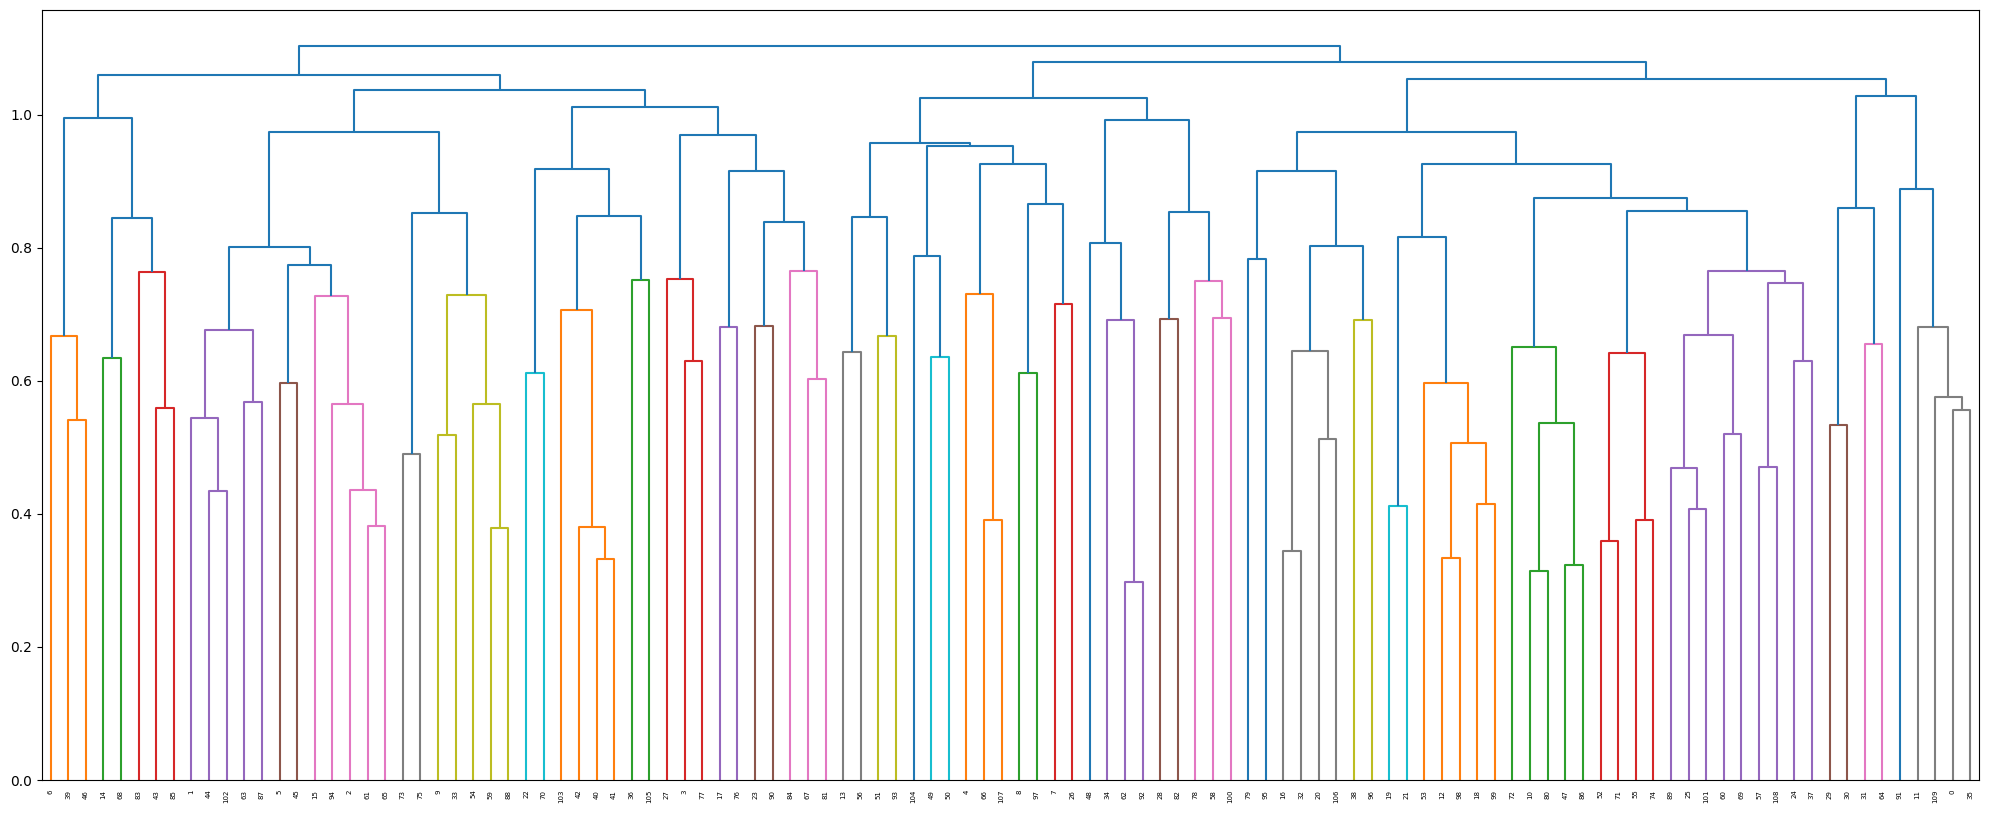

In [23]:
print(Z)
fig = plt.figure(figsize=(25, 10))
dn = dendrogram(Z)
plt.show()

In [ ]:
min_similarity = 0.2


all_cosine_similarity = df_sim
dist_matrix = 1.0 - all_cosine_similarity.values
np.fill_diagonal(dist_matrix, 0.0) 

condensed_dist = ssd.squareform(dist_matrix)
print(condensed_dist)
Z = linkage(condensed_dist, method='complete')
distance_threshold = 1.0 - min_similarity
cluster_labels = fcluster(Z, t=distance_threshold, criterion='distance')

clusters: dict[int, list[str]] = {}
words = all_cosine_similarity.index

for word, label in zip(words, cluster_labels):
    if label not in clusters:
        clusters[label] = []
    clusters[label].append(word)



[0.93450505 0.91524108 0.86827493 ... 0.92394931 0.93581402 0.92986619]


[10, 80, 30, 90, 5, 40]
[[ 1.  3.  5.  2.]
 [ 0.  4. 10.  3.]
 [ 2.  5. 40.  4.]]


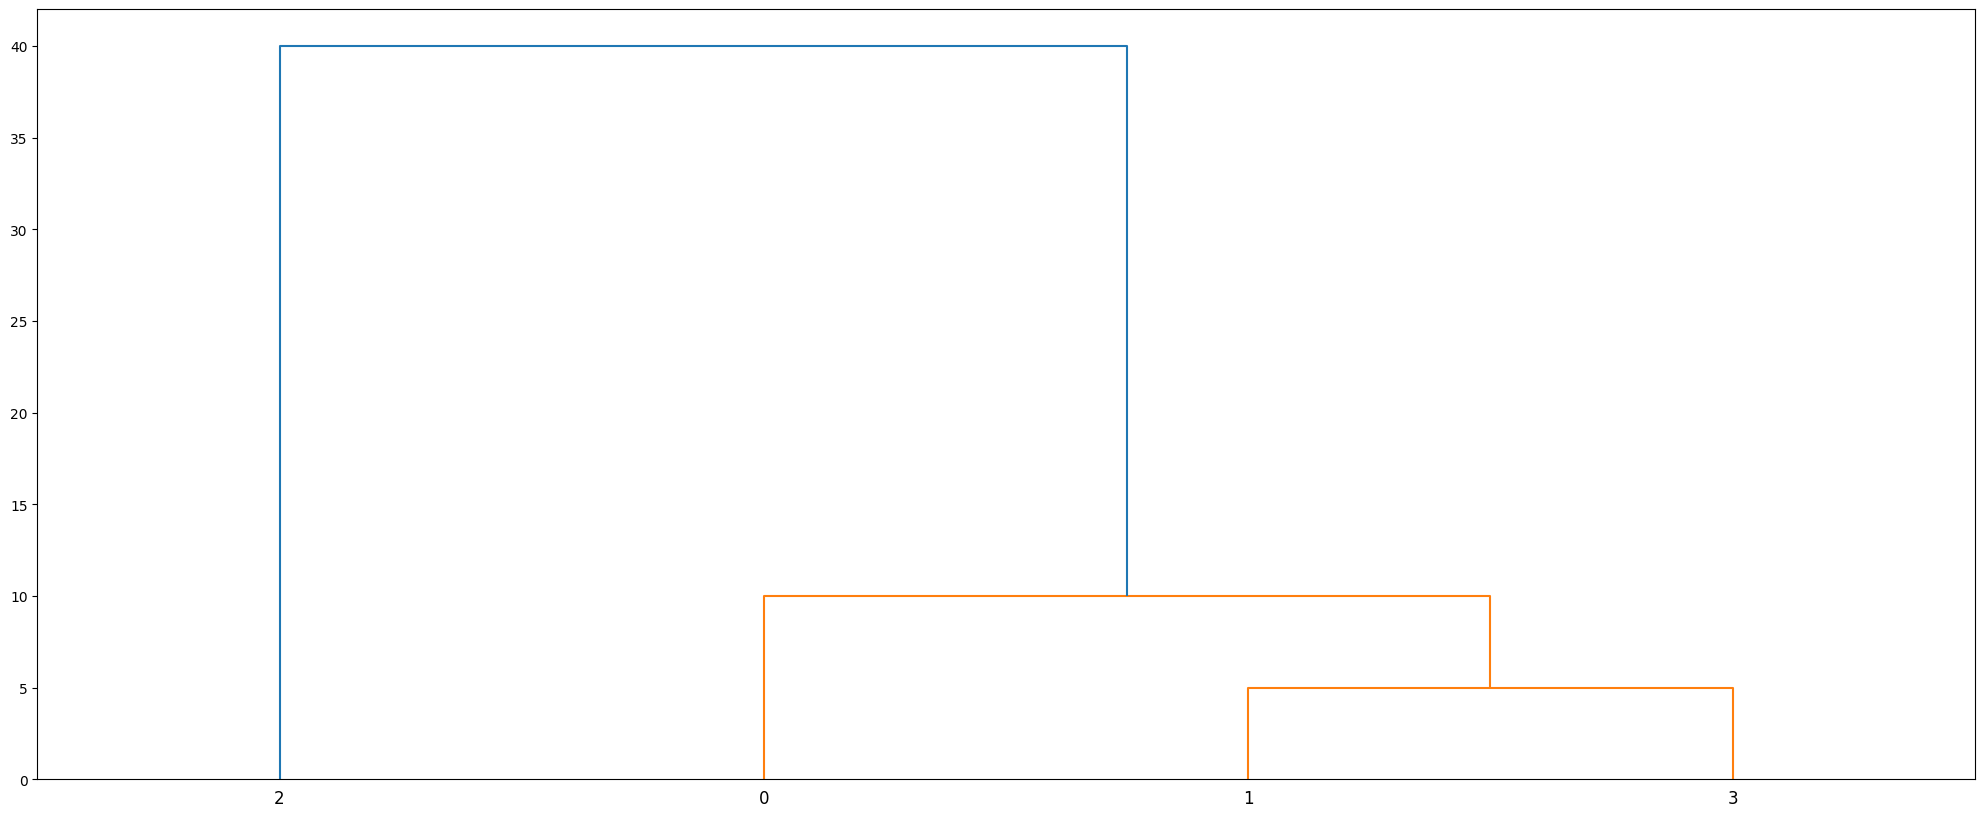

In [44]:
X = [[i, 1] for i in [2, 8, 0, 4, 1, 9, 10, 11]]
X = [10, 80, 30, 90, 5, 40]
print(X)
Z = linkage(X, 'single')
print(Z)
fig = plt.figure(figsize=(25, 10))
dn = dendrogram(Z)

In [ ]:
# tag_map = {
#         'n': 'NOUN',
#         'v': 'VERB',
#         'a': 'ADJ',  # Adjective
#         's': 'ADJ',  # Adjective satellite (treated the same as ADJ)
#         'r': 'ADV'   # Adverb
#     }

for name_coprus, clusters_info in cluster_by_corpus.items():
    print(f"---- {name_coprus} ----")
    for c in clusters_info:
        # print(f"{analyze_cluster_WordNet(c[-1])} | {c}")
        print(f"{analyze_cluster_pos_tag(c[-1])} | {c}")

In [ ]:
for word in ['did', 'do', 'does', 'going', 'not', 'want']:
    tagged = pos_tag([word], tagset='universal')
    print(tagged)
    print(wn.synsets(word))
    tag = tagged[0][1] 

In [ ]:
sub_matrix = list_df_sim[0].loc[['did', 'do', 'does', 'going', 'not', 'want'], ['did', 'do', 'does', 'going', 'not', 'want']]
mask = np.triu(np.ones(sub_matrix.shape), k=1).astype(bool)
print(sub_matrix)


sub_matrix = list_df_sim[0].loc[['cat', 'elephant', 'giraffe', 'gorilla', 'monkey'], ['cat', 'elephant', 'giraffe', 'gorilla', 'monkey']]
mask = np.triu(np.ones(sub_matrix.shape), k=1).astype(bool)
print(sub_matrix)

In [ ]:
# pos_tag(word_tokenize("John's big idea isn't all that bad.")) 
